# Route excursion analysis

Where and on which lanes cargo leaves its temperature band, how far, for how long, and how much the sensors
disagree while it happens. Uses the per-epoch track (centroid position and min/max temperature per evidence
epoch) and the epochs' conflict scores; no raw readings are needed (the API only publishes aggregates).

In [1]:
import os

import pandas as pd

from cargoflow import CargoFlow
from cargoflow import analytics as cfa

try:  # rich tables in Jupyter, plain text when run as a script
    from IPython.display import display as show
except ImportError:
    show = print

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

API = os.environ.get("CARGOFLOW_API_URL", "https://cargoflow-api-75ul.onrender.com")
cf = CargoFlow(API, timeout=90, retries=4, backoff=2)
pf = cf.portfolio()
print(f"{len(pf)} shipments")

4 shipments


## Excursions per lane and cargo band
An epoch is an excursion when its minimum is below the band or its maximum above it.

In [2]:
show(cfa.excursion_stats(pf))

,,shipments,epochs,excursion_epochs,excursion_rate,shipments_with_excursion,shipment_excursion_rate,mean_exceedance_c,max_exceedance_c,excursion_minutes,committed_excursions
route,cargo,,,,,,,,,,
"18.9,73.0 -> 1.3,103.8",2 to 8°C,3,17,3,0.18,3,1.00,3.70,3.70,1.75,1


In [3]:
show(cfa.excursion_stats(pf, by=["cargo"]))

,shipments,epochs,excursion_epochs,excursion_rate,shipments_with_excursion,shipment_excursion_rate,mean_exceedance_c,max_exceedance_c,excursion_minutes,committed_excursions
cargo,,,,,,,,,,
2 to 8°C,3,17,3,0.18,3,1.00,3.70,3.70,1.75,1


## The worst epochs

In [4]:
track = pf.track_frame()
worst = track[track["excursion"]].sort_values("exceedance_c", ascending=False)
show(worst[["shipment_id", "route", "milestone_index", "sequence", "start", "min_temp_c", "max_temp_c", "policy_min_c", "policy_max_c", "exceedance_c", "lat", "lon", "committed"]].head(10))

,shipment_id,route,milestone_index,sequence,start,min_temp_c,max_temp_c,policy_min_c,policy_max_c,exceedance_c,lat,lon,committed
2,0xbaee21438df729eaed5dc040ca1f99b934f556a15497...,"18.9,73.0 -> 1.3,103.8",255,3,2026-10-02 12:35:20+00:00,4.53,11.70,2.00,8.00,3.70,18.95,72.96,False
8,0x5a9082d1854c1cc3e5fcf8aa1ebc3a3560495e03ee7d...,"18.9,73.0 -> 1.3,103.8",2,1,2026-10-02 10:15:52+00:00,4.60,11.70,2.00,8.00,3.70,18.95,72.95,True
15,0xded44ff67a4e2e2f266097873494c2fbbc9326daf6a2...,"18.9,73.0 -> 1.3,103.8",255,2,2026-10-02 10:13:50+00:00,4.60,11.70,2.00,8.00,3.70,18.95,72.95,False


## Sensor conflict
Conflict is the disagreement between a shipment's sensors in an epoch (basis points). A high conflict next to an
excursion separates a real temperature event from one faulty probe.

In [5]:
show(cfa.conflict_distribution(pf, by="route"))

,epochs,mean_bps,std_bps,p50,p90,p95,p99,max_bps,share_above_policy
route,,,,,,,,,
"18.9,73.0 -> 1.3,103.8",9,959.67,"2,443.87",166.00,"1,627.80","4,551.40","6,890.28","7,475.00",0.11


In [6]:
show(cfa.conflict_histogram(pf))

,band,epochs,share
0,0-249,8,0.89
1,250-499,0,0.00
2,500-999,0,0.00
3,1000-1999,0,0.00
4,2000-2999,0,0.00
5,3000-4999,0,0.00
6,5000-7499,1,0.11
7,7500-10000,0,0.00


In [7]:
ep = pf.epochs_frame()
ep = ep[ep["evaluated"]]
joined = ep.merge(track[["epoch_id", "excursion", "exceedance_c"]], on="epoch_id", how="left")
show(joined.groupby(joined["excursion"].fillna(False))["conflict_bps"].describe())

,count,mean,std,min,25%,50%,75%,max
excursion,,,,,,,,
False,8.00,145.25,58.69,0.00,166.00,166.00,166.00,166.00
True,1.00,"7,475.00",NaN,"7,475.00","7,475.00","7,475.00","7,475.00","7,475.00"


## Per-sensor view of the worst shipment
`GET /v1/shipments/{id}/telemetry` gives min / mean / max per sensor and epoch.

In [8]:
if len(worst):
    sid = worst.iloc[0]["shipment_id"]
    tel = cf.telemetry(sid)
    rows = [{"epoch": e.epoch_id[:10], "milestone": e.milestone_index, "sensor": s.sensor_id, "readings": s.readings, "min_c": s.min_temp_x100 / 100, "mean_c": s.mean_temp_x100 / 100, "max_c": s.max_temp_x100 / 100} for e in tel.epochs for s in e.sensors]
    display_df = pd.DataFrame(rows)
else:
    display_df = pd.DataFrame()
show(display_df)

,epoch,milestone,sensor,readings,min_c,mean_c,max_c
0,0x94e69215,255,probe-1,8,4.94,5.02,5.11
1,0x94e69215,255,probe-2,8,4.71,4.77,4.86
2,0x765826c1,255,probe-1,8,4.94,5.01,5.08
3,0x765826c1,255,probe-2,8,4.69,4.77,4.84
4,0xa59d6d9b,255,probe-1,8,4.90,7.22,11.70
5,0xa59d6d9b,255,probe-2,8,4.53,4.68,4.84
6,0x74eff277,255,probe-1,8,5.02,5.42,6.43
7,0x74eff277,255,probe-2,8,4.58,4.65,4.72
8,0x663418fe,0,probe-1,8,4.98,5.08,5.16
9,0x663418fe,0,probe-2,8,4.78,4.89,4.97


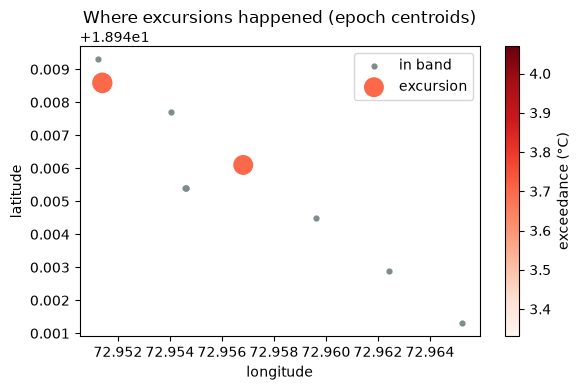

In [9]:
try:
    import matplotlib

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 4))
    ok = track[~track["excursion"]]
    ax.scatter(ok["lon"], ok["lat"], s=12, c="#7f8c8d", label="in band")
    sc = ax.scatter(worst["lon"], worst["lat"], s=30 + 40 * worst["exceedance_c"], c=worst["exceedance_c"], cmap="Reds", label="excursion")
    if len(worst):
        fig.colorbar(sc, ax=ax, label="exceedance (°C)")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title("Where excursions happened (epoch centroids)")
    ax.legend(loc="best")
    fig.tight_layout()
    os.makedirs("output", exist_ok=True)
    fig.savefig(os.path.join("output", "excursion_map.png"), dpi=120)
    show(fig)
    plt.close(fig)
except ImportError:
    print("matplotlib not installed; skipping the chart")